# 05 — Model Comparison: Baseline vs. LSTM

**Project:** Fake News Detection using Deep Learning (BCA Major Project)
**Phase:** Phase 6 — Comparative Analysis & Discussion (see the project specification)

## Purpose of this notebook

This notebook does **not** train a new model. Both the baseline (`models/baseline/`) and the
LSTM (`models/lstm/`) are loaded exactly as they were saved at the end of Phases 4 and 5 —
**frozen, read-only**. Everything here is either:

1. A **fresh, timed inference pass** of each frozen model over the identical test set (needed to
   measure inference time and to run paired statistical tests), or
2. **Re-reading** numbers already recorded in `models/*/metadata.json`, `evaluation/experiments.csv`,
   and the two phase reports (`docs/baseline_model_report.md`, `docs/lstm_model_report.md`).

The point of Phase 6 is to compare the two models fairly and explain *why* the results came out
the way they did — not to chase a better number by retraining either one.

**Frozen and untouched by this notebook:** `dataset/processed/03_preprocessed.csv`,
`models/baseline/`, `models/lstm/`, `evaluation/experiments.csv`, and every report asset from
Phases 4 and 5.


In [1]:
import sys
import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

sys.path.append(str(Path.cwd().parent))

from config.settings import (
    BASELINE_MODEL_DIR,
    LSTM_MODEL_DIR,
    MAX_SEQUENCE_LENGTH,
    REPORT_FIGURES_DIR,
    REPORT_TABLES_DIR,
    STAGE3_PREPROCESSED_FILE,
)
from training.split import stratified_three_way_split
from training.lstm import texts_to_padded_sequences
from evaluation.metrics import compute_classification_metrics
from evaluation.significance import mcnemar_test
from evaluation.agreement import (
    compute_agreement_counts,
    agreement_counts_to_dataframe,
    plot_agreement_bar,
)

pd.set_option("display.max_colwidth", 100)
REPORT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORT_TABLES_DIR.mkdir(parents=True, exist_ok=True)


## Step 1 — Reproduce the exact same test set both models were scored on

A comparison is only fair if both models are evaluated on **identical rows**. `training/split.py`
was deliberately written once and reused, unchanged, by both the baseline (Phase 4) and the LSTM
(Phase 5) notebooks — same function, same `RANDOM_SEED`, same input row order. Calling it again
here reproduces the exact same 5,796-row test set.


In [2]:
df = pd.read_csv(STAGE3_PREPROCESSED_FILE)
train_df, val_df, test_df = stratified_three_way_split(df, label_col="label")

y_test = test_df["label"].values
print(f"train/val/test rows: {len(train_df)}/{len(val_df)}/{len(test_df)}")
print(f"test set class balance: {test_df['label'].value_counts().to_dict()}")


train/val/test rows: 27046/5796/5796
test set class balance: {1: 3179, 0: 2617}


## Step 2 — Load both frozen models (no training happens in this notebook)


In [3]:
baseline_vectorizer = joblib.load(BASELINE_MODEL_DIR / "tfidf_vectorizer.pkl")
baseline_model = joblib.load(BASELINE_MODEL_DIR / "logistic_regression.pkl")

lstm_model = tf.keras.models.load_model(LSTM_MODEL_DIR / "model.keras")
lstm_tokenizer = joblib.load(LSTM_MODEL_DIR / "tokenizer.pkl")

print("Baseline and LSTM artifacts loaded (read-only).")


Baseline and LSTM artifacts loaded (read-only).


## Step 3 — Generate predictions and measure inference time

"Inference time" is measured the same way for both models: from raw preprocessed text
(`baseline_text` / `lstm_text`, already produced by Stage 3) to a final class prediction. For the
baseline that means TF-IDF transform + `predict`; for the LSTM that means tokenize + pad +
`predict`. Excluding either model's own necessary preprocessing step would make the comparison
unfair in the opposite direction.


In [4]:
start = time.time()
X_test_tfidf = baseline_vectorizer.transform(test_df["baseline_text"])
baseline_pred = baseline_model.predict(X_test_tfidf)
baseline_proba = baseline_model.predict_proba(X_test_tfidf)[:, 1]
baseline_inference_seconds = time.time() - start

print(f"Baseline inference time (5,796 articles): {baseline_inference_seconds:.4f} s")
print(f"  -> {baseline_inference_seconds / len(test_df) * 1000:.4f} ms/article")


Baseline inference time (5,796 articles): 1.2904 s
  -> 0.2226 ms/article


In [5]:
start = time.time()
X_test_seq = texts_to_padded_sequences(lstm_tokenizer, test_df["lstm_text"])
lstm_proba = lstm_model.predict(X_test_seq, verbose=0).flatten()
lstm_pred = (lstm_proba >= 0.5).astype(int)
lstm_inference_seconds = time.time() - start

print(f"LSTM inference time (5,796 articles): {lstm_inference_seconds:.4f} s")
print(f"  -> {lstm_inference_seconds / len(test_df) * 1000:.4f} ms/article")


LSTM inference time (5,796 articles): 8.2592 s
  -> 1.4250 ms/article


## Step 4 — Integrity check: do fresh predictions match the archived metadata?

Before trusting any comparison built on these fresh predictions, confirm they reproduce the
exact numbers already saved in `models/*/metadata.json` at the end of Phases 4 and 5. This is the
same sanity check the Reuters ablation study used before drawing any conclusions — if these
didn't match, it would mean the split, the artifacts, or this notebook's code disagreed with the
original training run, and nothing downstream could be trusted.


In [6]:
baseline_metrics_fresh = compute_classification_metrics(y_test, baseline_pred)
lstm_metrics_fresh = compute_classification_metrics(y_test, lstm_pred)

with open(BASELINE_MODEL_DIR / "metadata.json") as f:
    baseline_metadata = json.load(f)
with open(LSTM_MODEL_DIR / "metadata.json") as f:
    lstm_metadata = json.load(f)

for name, value in baseline_metrics_fresh.items():
    archived = baseline_metadata["test_set_metrics"][name]
    assert abs(value - archived) < 1e-9, f"Baseline {name} mismatch: {value} vs {archived}"
print("Baseline: fresh predictions match models/baseline/metadata.json exactly.")

for name, value in lstm_metrics_fresh.items():
    archived = lstm_metadata["test_set_metrics"][name]
    assert abs(value - archived) < 1e-6, f"LSTM {name} mismatch: {value} vs {archived}"
print("LSTM: fresh predictions match models/lstm/metadata.json (within floating-point tolerance).")


Baseline: fresh predictions match models/baseline/metadata.json exactly.
LSTM: fresh predictions match models/lstm/metadata.json (within floating-point tolerance).


## Step 5 — Complexity metrics: model size, parameter counts, vocabulary

Read directly from the artifacts on disk and from the loaded objects — no retraining needed.

A note on "trainable parameters": Logistic Regression doesn't have "trainable parameters" in the
backpropagation sense the LSTM does, but it has a direct structural analogue — one learned
coefficient per TF-IDF feature, plus one intercept. Both are, in the end, a table of learned
numeric weights the model multiplies its input by.


In [7]:
baseline_files = ["tfidf_vectorizer.pkl", "logistic_regression.pkl"]
lstm_files = ["model.keras", "tokenizer.pkl"]

baseline_model_only_bytes = (BASELINE_MODEL_DIR / "logistic_regression.pkl").stat().st_size
baseline_total_bytes = sum((BASELINE_MODEL_DIR / f).stat().st_size for f in baseline_files)

lstm_model_only_bytes = (LSTM_MODEL_DIR / "model.keras").stat().st_size
lstm_total_bytes = sum((LSTM_MODEL_DIR / f).stat().st_size for f in lstm_files)

baseline_param_count = len(baseline_vectorizer.vocabulary_) + 1  # +1 for the intercept
lstm_param_count = lstm_model.count_params()

baseline_vocab_size = len(baseline_vectorizer.vocabulary_)
lstm_vocab_capped = lstm_tokenizer.num_words
lstm_vocab_actual = len(lstm_tokenizer.word_index) + 1

print("Model-only size (bytes):      baseline", baseline_model_only_bytes, "| LSTM", lstm_model_only_bytes)
print("Total inference artifacts:    baseline", baseline_total_bytes, "| LSTM", lstm_total_bytes)
print("Parameter/coefficient count:  baseline", baseline_param_count, "| LSTM", lstm_param_count)
print("Vocabulary size (capped):     baseline", baseline_vocab_size, "| LSTM", lstm_vocab_capped, f"(of {lstm_vocab_actual} distinct words seen)")


Model-only size (bytes):      baseline 160863 | LSTM 24569131
Total inference artifacts:    baseline 904554 | LSTM 28685801
Parameter/coefficient count:  baseline 20001 | LSTM 2044353
Vocabulary size (capped):     baseline 20000 | LSTM 20000 (of 96250 distinct words seen)


## Step 6 — Build the comprehensive comparison table

`Training Epochs` and `Best Validation Epoch` are not applicable to the baseline — Logistic
Regression here is fit with a single deterministic `lbfgs` solver call, not an epoch-by-epoch
loop, so there is no "epoch" concept to report.

The LSTM's best validation epoch (8, by `val_loss`) is not stored as a separate field in
`models/lstm/metadata.json` (only the best value, 0.1100, is) — it is carried forward here from
the original training run's captured console output (`notebooks/04_lstm_training.ipynb`, cell 15;
also documented in `docs/lstm_model_report.md`), **not recomputed by retraining**.


In [8]:
BEST_VAL_EPOCH_LSTM = 8  # sourced from notebooks/04_lstm_training.ipynb cell 15 output; see markdown above

# training_time_seconds isn't stored in metadata.json for either model - pull from experiments.csv.
experiments_df = pd.read_csv(Path.cwd().parent / "evaluation" / "experiments.csv")
baseline_row = experiments_df[experiments_df["model"] == "TF-IDF + Logistic Regression (baseline)"].iloc[0]
lstm_row = experiments_df[experiments_df["model"] == "LSTM"].iloc[0]

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC",
        "Training Time (s)", "Inference Time - total (s)", "Inference Time (ms/article)",
        "Model Size - model file only (MB)", "Model Size - total inference artifacts (MB)",
        "Trainable Parameters / Coefficients", "Vocabulary Size (capped)",
        "Training Epochs", "Best Validation Epoch",
    ],
    "Baseline (TF-IDF + Logistic Regression)": [
        baseline_metrics_fresh["accuracy"], baseline_metrics_fresh["precision"],
        baseline_metrics_fresh["recall"], baseline_metrics_fresh["f1_score"],
        baseline_metadata["test_set_auc"],
        float(baseline_row["training_time_seconds"]),
        baseline_inference_seconds, baseline_inference_seconds / len(test_df) * 1000,
        baseline_model_only_bytes / 1e6, baseline_total_bytes / 1e6,
        baseline_param_count, baseline_vocab_size,
        "N/A (single lbfgs solver call, not epoch-based)", "N/A",
    ],
    "LSTM": [
        lstm_metrics_fresh["accuracy"], lstm_metrics_fresh["precision"],
        lstm_metrics_fresh["recall"], lstm_metrics_fresh["f1_score"],
        lstm_metadata["test_set_auc"],
        float(lstm_row["training_time_seconds"]),
        lstm_inference_seconds, lstm_inference_seconds / len(test_df) * 1000,
        lstm_model_only_bytes / 1e6, lstm_total_bytes / 1e6,
        lstm_param_count, lstm_vocab_capped,
        lstm_metadata["epochs_completed"], BEST_VAL_EPOCH_LSTM,
    ],
})

comparison_df.to_csv(REPORT_TABLES_DIR / "model_comparison.csv", index=False)
comparison_df


,Metric,Baseline (TF-IDF + Logistic Regression),LSTM
0,Accuracy,0.982402,9.720497e-01
1,Precision,0.978836,9.757174e-01
2,Recall,0.989305,9.732620e-01
3,F1 Score,0.984043,9.744882e-01
4,ROC-AUC,0.997929,9.917050e-01
5,Training Time (s),0.245526,5.991239e+02
6,Inference Time - total (s),1.290357,8.259231e+00
7,Inference Time (ms/article),0.222629,1.424988e+00
8,Model Size - model file only (MB),0.160863,2.456913e+01
9,Model Size - total inference artifacts (MB),0.904554,2.868580e+01


## Step 7 — Figure: performance metrics side by side


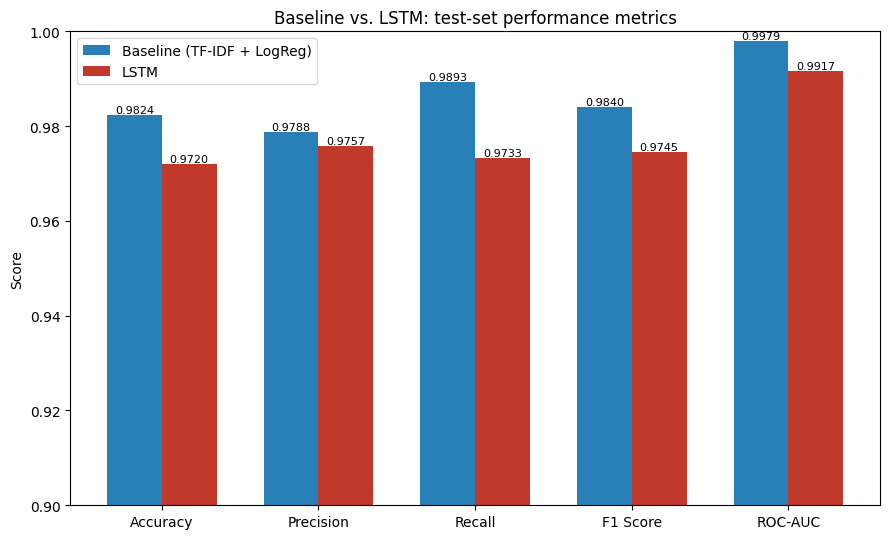

In [9]:
metric_names = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
baseline_values = [
    baseline_metrics_fresh["accuracy"], baseline_metrics_fresh["precision"],
    baseline_metrics_fresh["recall"], baseline_metrics_fresh["f1_score"],
    baseline_metadata["test_set_auc"],
]
lstm_values = [
    lstm_metrics_fresh["accuracy"], lstm_metrics_fresh["precision"],
    lstm_metrics_fresh["recall"], lstm_metrics_fresh["f1_score"],
    lstm_metadata["test_set_auc"],
]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
bars_a = ax.bar(x - width/2, baseline_values, width, label="Baseline (TF-IDF + LogReg)", color="#2980b9")
bars_b = ax.bar(x + width/2, lstm_values, width, label="LSTM", color="#c0392b")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0.9, 1.0)
ax.set_ylabel("Score")
ax.set_title("Baseline vs. LSTM: test-set performance metrics")
ax.legend()
for bars in (bars_a, bars_b):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.4f}",
                ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(REPORT_FIGURES_DIR / "model_accuracy_comparison.png", dpi=150)
plt.show()


## Step 8 — Figure: training time comparison

Training time spans nearly four orders of magnitude (0.25 s vs. ~599 s), so a linear-scale bar
chart would render the baseline's bar as invisible. A log-scale y-axis is used instead — this is
also an opportunity to teach why log scales exist: they compress large ratios into a readable
range without hiding *how big* the ratio actually is (the axis labels still show the true values).


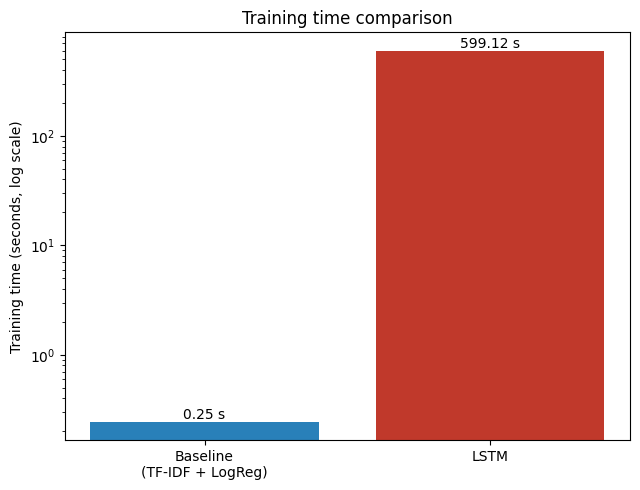

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5))
models = ["Baseline\n(TF-IDF + LogReg)", "LSTM"]
times = [float(baseline_row["training_time_seconds"]), float(lstm_row["training_time_seconds"])]
bars = ax.bar(models, times, color=["#2980b9", "#c0392b"])
ax.set_yscale("log")
ax.set_ylabel("Training time (seconds, log scale)")
ax.set_title("Training time comparison")
for bar, value in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{value:.2f} s",
            ha="center", va="bottom")
fig.tight_layout()
fig.savefig(REPORT_FIGURES_DIR / "model_training_time_comparison.png", dpi=150)
plt.show()


## Step 9 — Statistical comparison: McNemar's test

A plain accuracy difference (98.24% vs. 97.20%) can't by itself say whether the baseline is
*genuinely* better or whether this particular 5,796-row test set just happened to favor it by
chance. **McNemar's test** answers this properly: it looks only at the *discordant* rows - where
the two models disagree - and asks whether one model is wrong on those disagreement rows
noticeably more often than the other. Rows where both models agree (right or wrong) provide no
evidence either way and are excluded entirely.

**Null hypothesis (H0):** among the rows where the two models disagree, each model is equally
likely to be the one that's correct (i.e. the disagreements are a coin flip, not systematic).
A small p-value would mean this is unlikely, i.e. one model is systematically stronger on the
rows where they differ.

This is the same test, from the same module (`evaluation/significance.py`), used in
`docs/reuters_ablation_study.md` — reused unchanged here, exactly as the project specification's Phase 6 spec
requires.


In [11]:
mcnemar_result = mcnemar_test(y_test, baseline_pred, lstm_pred)
mcnemar_result


{'a_correct_b_wrong': 118,
 'a_wrong_b_correct': 58,
 'n_discordant': 176,
 'chi2_statistic': 19.77840909090909,
 'chi2_p_value': np.float64(8.695945942104947e-06),
 'exact_p_value': np.float64(7.171360612650806e-06)}

In [12]:
n_b = mcnemar_result["a_correct_b_wrong"]
n_c = mcnemar_result["a_wrong_b_correct"]
n_discordant = mcnemar_result["n_discordant"]
p_value = mcnemar_result["exact_p_value"]

print(f"Rows where baseline was right and LSTM was wrong: {n_b}")
print(f"Rows where LSTM was right and baseline was wrong: {n_c}")
print(f"Total discordant rows: {n_discordant} out of {len(test_df)}")
print(f"McNemar exact p-value: {p_value:.6f}")
print()
if p_value < 0.05:
    print("p < 0.05: reject H0 - the disagreement pattern is NOT consistent with a coin flip;")
    print("one model is systematically stronger on the rows where they differ.")
else:
    print("p >= 0.05: fail to reject H0 at this size of test set.")


Rows where baseline was right and LSTM was wrong: 118
Rows where LSTM was right and baseline was wrong: 58
Total discordant rows: 176 out of 5796
McNemar exact p-value: 0.000007

p < 0.05: reject H0 - the disagreement pattern is NOT consistent with a coin flip;
one model is systematically stronger on the rows where they differ.


## Step 10 — Prediction agreement analysis

McNemar's test only looks at *discordant* rows. This section looks at **all four** possible
outcomes for every test article: do the models mostly succeed and fail together, or does each
one have its own distinct blind spot?


In [13]:
agreement_counts = compute_agreement_counts(y_test, baseline_pred, lstm_pred)
agreement_df = agreement_counts_to_dataframe(agreement_counts, "Baseline", "LSTM")
agreement_df.to_csv(REPORT_TABLES_DIR / "prediction_agreement.csv", index=False)
agreement_df


,category,count,percentage
0,Both models correct,5576,96.20
1,Both models wrong,44,0.76
2,Only Baseline correct,118,2.04
3,Only LSTM correct,58,1.00


In [14]:
plot_agreement_bar(agreement_counts, "Baseline", "LSTM", REPORT_FIGURES_DIR / "error_overlap.png")
plt.imread(REPORT_FIGURES_DIR / "error_overlap.png").shape  # confirm it saved


(750, 1050, 4)

## Step 11 — Representative examples from each disagreement bucket

Concrete examples for the Error Analysis section of the comparison report — do the two models'
blind spots look qualitatively different, or the same?


In [15]:
a_correct = baseline_pred == y_test
b_correct = lstm_pred == y_test

both_wrong_mask = (~a_correct) & (~b_correct)
baseline_only_mask = a_correct & (~b_correct)   # LSTM's exclusive mistakes
lstm_only_mask = (~a_correct) & b_correct        # baseline's exclusive mistakes

examples = []
for name, mask in [
    ("Both models wrong", both_wrong_mask),
    ("Only baseline correct (LSTM's exclusive mistake)", baseline_only_mask),
    ("Only LSTM correct (baseline's exclusive mistake)", lstm_only_mask),
]:
    subset = test_df.loc[mask].head(4).copy()
    subset["bucket"] = name
    subset["true_label"] = y_test[mask][:4]
    examples.append(subset[["bucket", "title", "true_label"]])

examples_df = pd.concat(examples, ignore_index=True)
examples_df.to_csv(REPORT_TABLES_DIR / "comparison_error_examples.csv", index=False)
examples_df


,bucket,title,true_label
0,Both models wrong,Benghazi Survivor On Hillary Clinton: “I Don’t Think She Has A Soul”,0
1,Both models wrong,Obamas donated less to charities in 2015 as income slipped,1
2,Both models wrong,Trump booster apologizes for Clinton 'blackface' tweet,1
3,Both models wrong,Undercutting the Nation State? Chicago Group Suggests ‘Global Cities’ Should Run World Affairs,0
4,Only baseline correct (LSTM's exclusive mistake),Merkel scolds ally to shield coalition talks from weedkiller row,1
5,Only baseline correct (LSTM's exclusive mistake),Trump Condemned By Jewish Leaders In Poland After Snubbing Warsaw Ghetto Memorial,0
6,Only baseline correct (LSTM's exclusive mistake),MITCH MCCONNELL: The Senate Will Not Take Up Nomination of Merrick Garland,0
7,Only baseline correct (LSTM's exclusive mistake),Obama warns Democrats against overconfidence about Clinton victory,1
8,Only LSTM correct (baseline's exclusive mistake),FLAMING RINO ALERT! LINDSEY GRAHAM: ‘TRUMP IS GOING TO KILL MY PARTY’,0
9,Only LSTM correct (baseline's exclusive mistake),BREAKING: House Republicans Work To Cut Off Federal Funding For Syrian Refugee Resettlement Program,0


## Summary of this notebook's outputs

- `report/tables/model_comparison.csv` — full side-by-side metrics/complexity table
- `report/tables/prediction_agreement.csv` — 4-way agreement breakdown
- `report/tables/comparison_error_examples.csv` — representative titles from each disagreement bucket
- `report/figures/model_accuracy_comparison.png`
- `report/figures/model_training_time_comparison.png`
- `report/figures/error_overlap.png`

No model was retrained. `models/baseline/`, `models/lstm/`, and `evaluation/experiments.csv` are
unchanged by this notebook. The discussion and conclusions built from these numbers live in
`docs/model_comparison_report.md`.
